In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features.copy() 
y = heart_disease.data.targets.values.ravel().copy()
y = (y> 0).astype(int)
  
# metadata 
# print(heart_disease.metadata) 
# variable information 
# print(heart_disease.variables) 
# df = pd.concat([X, y], axis=1) # dataset creation
# df
print("Shape of the Dataset:",X.shape)
print("Dataset Info: \n\n",X.info())
print("Checking for null values:\n\n",X.isnull().sum())
print("Checking for duplicates\n\n")
print(X.duplicated())
print(X.drop_duplicates())
X

Shape of the Dataset: (303, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
Dataset Info: 

 None
Checking for null values:

 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal    

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

num_col = ['age', 'sex', 'cp', 'trestbps','chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope','ca', 'thal']

num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessing = ColumnTransformer(
    transformers=[
        ('process_num_data', num_pipeline, num_col)
    ]
)
knn = KNeighborsClassifier(n_neighbors=7)
lr = LogisticRegression(max_iter=1000, random_state=42)
cart = DecisionTreeClassifier(random_state=42,criterion='gini')
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
xgb = XGBClassifier(n_estimators=1000, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')
sc = StackingClassifier(estimators=[
    ('knn', knn),
    ('lr', lr),
    ('cart', cart),
    ('rf', rf)
],
final_estimator=xgb,
cv=5,
n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', sc)
    ]
)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('process_num_data', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

The accuracy score is: 80.33%


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80        33
           1       0.74      0.89      0.81        28

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.82      0.80      0.80        61



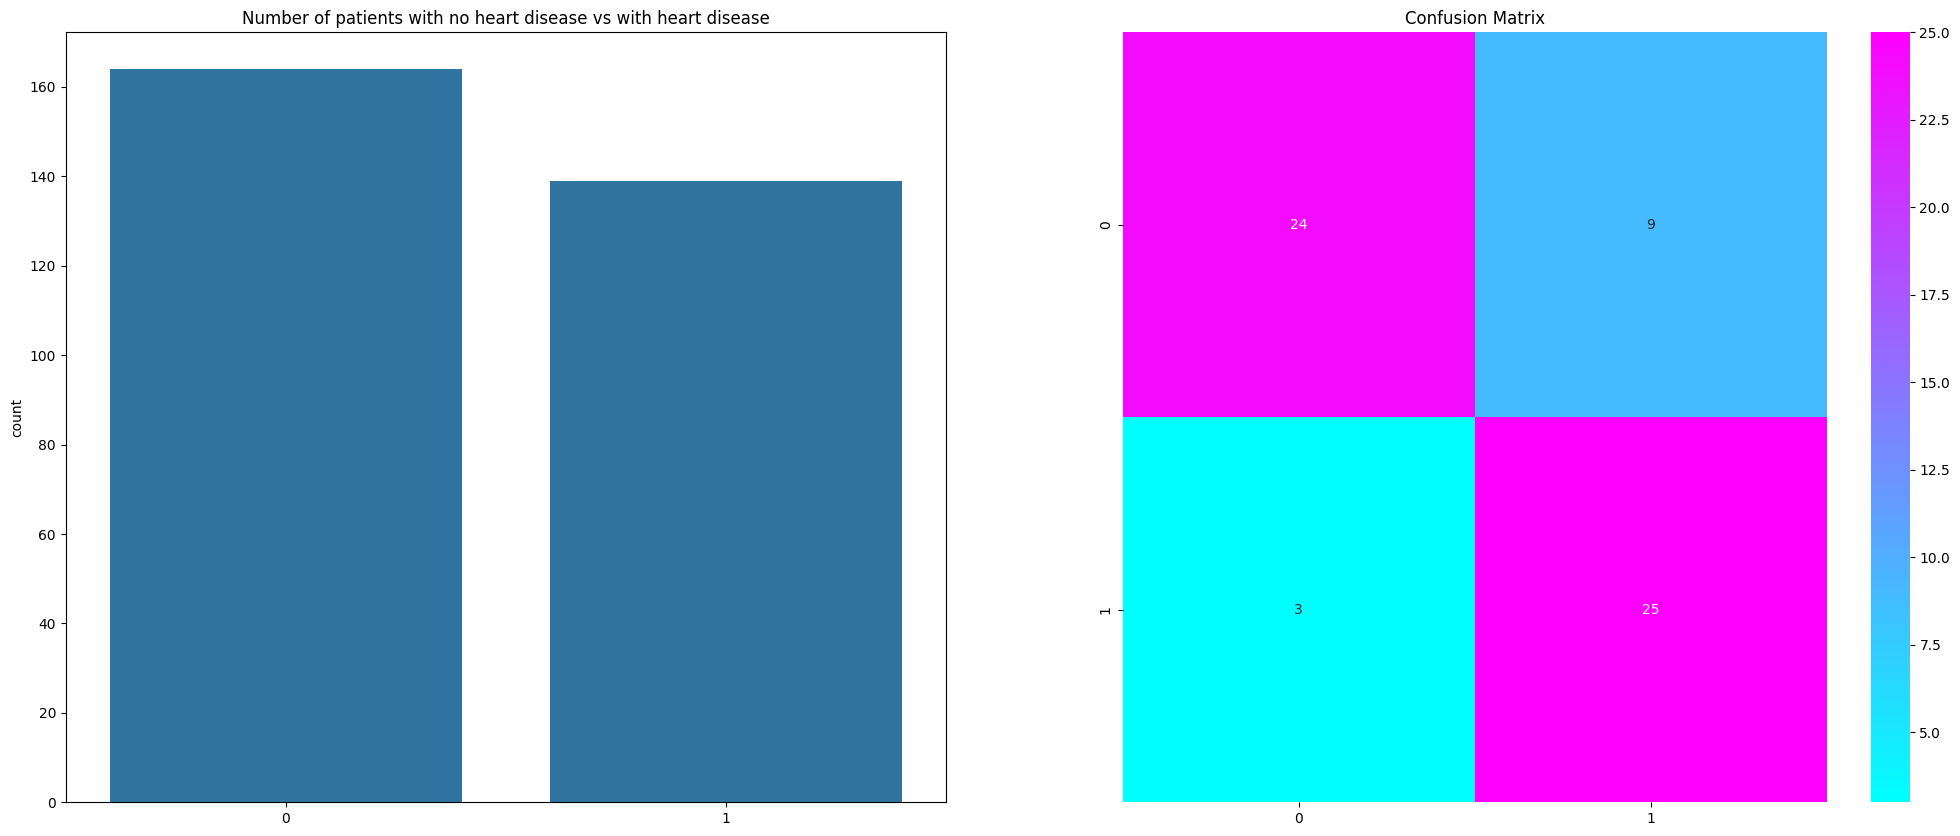

In [3]:
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test,y_pred)
print(f"The accuracy score is: {acc*100:.2f}%")
cr = classification_report(y_test,y_pred)
print(f"\n\nClassification Report:\n{cr}")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(25,10))
plt.subplot(1,2,1)
plt.title("Number of patients with no heart disease vs with heart disease")
sns.countplot(x=y)
plt.subplot(1,2,2)
sns.heatmap(data=cm, annot=True,cmap='cool')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
ns = pd.DataFrame({
    'age': [25],
    'sex': [1],
    'cp': [2],
    'trestbps': [130],
    'chol': [205],
    'fbs': [1],
    'restecg': [0],
    'thalach': [136],
    'exang': [1],
    'oldpeak':[1.2],
    'slope': [3],
    'ca': [2],
    'thal': [3]
})
ns = ns[X.columns]
output = pipeline.predict(ns)
print(f"Prediction: {output[0]}")
joblib.dump(pipeline, "pipeline.pkl")
joblib.dump(list(X.columns), 'col_names.pkl')

Prediction: 1


['col_names.pkl']